# Setup

In [1]:
import numpy as np
import pickle
import os
import gc
from scipy.special import spherical_jn
import camb
from camb import model, initialpower
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===================== SETUP =====================
rmin = 0.
rmax = 200.
numr = 150
numri = 80
r = np.linspace(rmin, rmax, numr) + 5
ri = np.linspace(rmin, rmax, numri) + 5

kmin = 1e-4
kmax = 3.
numk = 200
k = np.logspace(np.log10(kmin), np.log10(kmax), numk)


#Now get matter power spectra and sigma8 at redshift 0 and 0.8
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
pars.InitPower.set_params(ns=0.965)

#Note non-linear corrections couples to smaller scales than you want
pars.set_matter_power(kmax=kmax)

#Linear spectra
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)

#Obtain Power Spectrum with pk below
kh, z, Plin_k = results.get_matter_power_spectrum(minkh=1e-4, maxkh=3, npoints = numk)

Pk = Plin_k[0,:]


num_ell = 7
j = np.zeros((num_ell, numr, numk))
jri = np.zeros((num_ell, numri, numk))

for ell in range(num_ell):
    i = 0
    for rval in r:
        j[ell, i, :] = spherical_jn(ell, k*rval)
        i += 1

for ell in range(num_ell):
    i = 0
    for rval in ri:
        jri[ell, i, :] = spherical_jn(ell, k*rval)
        i += 1

num_pow = 9
k_pow = np.zeros((num_pow, numk))
r_pow = np.zeros((num_pow, numr))
ri_pow = np.zeros((num_pow, numri))

k_pow[0, :] = np.ones(numk)
k_pow[1, :] = k

r_pow[0, :] = np.ones(numr)
r_pow[1, :] = r

ri_pow[0, :] = np.ones(numri)
ri_pow[1, :] = ri

for i in range(1, num_pow - 1):
    k_pow[i + 1, :] = k_pow[i, :]*k
    r_pow[i + 1, :] = r_pow[i, :]*r
    ri_pow[i + 1, :] = ri_pow[i, :]*ri

dr = (np.max(r) - np.min(r))/len(r)
tpi = 1/(2*np.pi**2)
dlnk = (np.log(k[1]) - np.log(k[0]))

# Definition of Integral 

### Variance on sphere of radius R

### $\sigma(R) =\left<(\delta^2_{\rm lin})\right>(R)= 9/2\pi^2\;\int P(k)\;\left(\frac{j_{1}(kR)}{kR}\right)^2 \; k^2 dk \approx 9/2\pi^2\; dk \sum_{k} P(k)\;\left(\frac{j_{1}(kR)}{kR}\right)^2 \; k^2 $

In [2]:
def V_of_R(Rvals, k, Pk, dlnk): #k is in log space
    Rvals = np.atleast_1d(Rvals).astype(float)          # (nR,)
    x = Rvals[:, None] * k[None, :]                     # (nR, nk)
    j1 = spherical_jn(1, x)
    integrand = Pk[None, :] * (j1 / x)**2 * k[None, :]**3   # k^2 dk = k^3 dlnk
    return 9.0 * tpi * dlnk * np.sum(integrand, axis=1)     # (nR,)


# Search for R Values 

In [3]:
#Values to obtain from Integral
targets = np.array([0.1, 0.2, 0.3, 0.4, 0.5], dtype=float)

In [4]:
#Evaluate Integral
Rmin, Rmax = 0.1, 200
nRgrid = 1000
Rgrid = np.linspace(Rmin,Rmax,nRgrid)

Vgrid = V_of_R(Rgrid, k, Pk, dlnk)

In [6]:
#Find the true Value of R for the set targets
#First we interpolate, so we can extract specific values
#Interpolation needs to be monotonically increasing
Vgrid = Vgrid[::-1]
Rgrid = Rgrid[::-1]

Vgrid[0]>Vgrid[-1], Rgrid[0]>Rgrid[-1] #False, True expected

(False, True)

In [7]:
Vinv_interp = interp1d(Vgrid, Rgrid, kind="linear", bounds_error=False, fill_value=np.nan)

In [8]:
R_solutions = Vinv_interp(targets)
targets, R_solutions

(array([0.1, 0.2, 0.3, 0.4, 0.5]),
 array([25.00696119, 17.05853264, 13.35884481, 11.10964051,  9.56420921]))

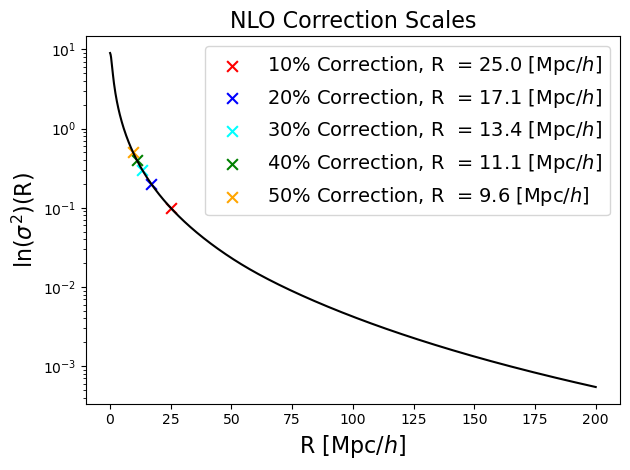

In [9]:
plt.plot(Rgrid, Vgrid,color = 'black')
plt.scatter(R_solutions[0], targets[0],marker = 'x', s=60, color = 'red',label = f"{100*targets[0]:.0f}$\%$ Correction, R  = {round(R_solutions[0],1)} [Mpc/$h$]")
plt.scatter(R_solutions[1], targets[1],marker = 'x', s=60, color = 'blue',label = f"{100*targets[1]:.0f}$\%$ Correction, R  = {round(R_solutions[1],1)} [Mpc/$h$]")
plt.scatter(R_solutions[2], targets[2],marker = 'x', s=60, color = 'cyan',label = f"{100*targets[2]:.0f}$\%$ Correction, R  = {round(R_solutions[2],1)} [Mpc/$h$]")
plt.scatter(R_solutions[3], targets[3],marker = 'x', s=60, color = 'green',label = f"{100*targets[3]:.0f}$\%$ Correction, R  = {round(R_solutions[3],1)} [Mpc/$h$]")
plt.scatter(R_solutions[4], targets[4],marker = 'x', s=60, color = 'orange',label = f"{100*targets[4]:.0f}$\%$ Correction, R  = {round(R_solutions[4],1)} [Mpc/$h$]")
plt.yscale('log')
#plt.grid('True')
plt.xlabel(r"R [Mpc/$h$]",fontsize=16)
plt.ylabel(r"ln($\sigma^2$)(R)",fontsize=16)
plt.title('NLO Correction Scales', fontsize=16)
plt.legend(loc='best',fontsize=14)
plt.tight_layout()
plt.savefig('NLO_Correction_Scale.pdf')